# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AbdullahIdrees291/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Abstract

This study asks whether historical search-performance signals can help rank pages for content review. Using anonymized FlyRank warehouse data, I aggregated page-level search and engagement signals and trained a machine-learning model to identify pages associated with positive next-month click outcomes. The model achieved a ROC-AUC of 0.801 and 36.2% precision on the held-out period, compared with a majority-class baseline accuracy of 0.891. The results suggest that impressions and organic sessions were the strongest measured signals for the model's ranking decisions. The resulting scores are intended as directional decision-support recommendations for content review, not as causal evidence that refreshing a page will improve future performance.

## 1. Question

## Research Question

**Can historical search-performance signals be used to rank pages that are the strongest candidates for content refresh or review?**

### Decision supported

The goal is to help a content team decide **which pages should be reviewed first** by producing a ranked refresh-opportunity score based on measurable search-performance signals.

This is a **decision-support analysis**. It does not claim to explain or predict Google's ranking algorithm, and it does not establish causal effects of content changes.


## 2. Data

This analysis uses the approved FlyRank internship warehouse release available through Hugging Face. The analysis focuses on anonymized search-performance data and uses aggregated page-level observations over the available reporting windows.

Only fields needed for the refresh-opportunity analysis are used. Client-identifying information, domains, URLs, private search queries, credentials, and raw private exports are excluded from the analysis and are not published.

The analysis uses historical observations to construct measurable performance signals and evaluates the refresh-ranking approach on a held-out evaluation period. Exact date windows, tables, and exclusions are recorded in the notebook alongside the data-loading and aggregation code so the analysis remains reproducible.


In [1]:
# Basic packages
import pandas as pd
import numpy as np
import duckdb

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Check the Hugging Face / DuckDB setup
import os

print("Python environment is ready.")
print("Current working directory:", os.getcwd())

Python environment is ready.
Current working directory: /content


In [17]:
import os

# Clone your GitHub repository into Colab
!git clone https://github.com/AbdullahIdrees291/flyrank-ml-internship.git

# Move into the repository
%cd /content/flyrank-ml-internship

# Check important folders/files
print("Repository contents:")
print(os.listdir())

print("\nWork notebooks:")
print(os.listdir("work/notebooks")[:20])

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 144 (delta 52), reused 95 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (144/144), 1.87 MiB | 9.78 MiB/s, done.
Resolving deltas: 100% (52/52), done.
/content/flyrank-ml-internship
Repository contents:
['DATA_USE.md', 'GUIDE.md', 'work', 'requirements.txt', 'outputs', 'submission', 'notebooks', 'w02_ml_task_framing.ipynb', '.gitignore', '.github', 'docs', '.git', 'AGENTS.md', '01_first_look_and_discovery.ipynb', 'CLAUDE.md', '02_your_first_readable_model.ipynb', 'flyrank-ml-internship', 'LICENSE', 'skills', 'README.md', 'SETUP.md', 'w03_data_contract.ipynb', 'data', 'scripts']

Work notebooks:
['w01_research_question.ipynb', 'w04_baseline_score.ipynb', 'w02_ml_task_framing.ipynb', 'w06_validation_audit.ipynb', 'w04_signal_audit.ipynb', 'w07_action_playbook.ipynb', 'w03_feature_leakage_

In [19]:
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")

print("✅ Hugging Face token found.")

✅ Hugging Face token found.


In [20]:
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")

print("HF token found:", bool(hf_token))

HF token found: True


In [21]:
from huggingface_hub import login

login(token=hf_token)

In [22]:
from huggingface_hub import HfApi

api = HfApi(token=hf_token)

info = api.dataset_info("FlyRank/internship-warehouse")

print("Warehouse access OK ✅")
print("Dataset:", info.id)

Warehouse access OK ✅
Dataset: FlyRank/internship-warehouse


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [23]:
# Step 3A — Inspect the available warehouse dataset

from huggingface_hub import hf_hub_download
import os

print("Checking FlyRank warehouse files...")

files = api.list_repo_files(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset"
)

print("Available files:")
for f in files[:30]:
    print(f)

Checking FlyRank warehouse files...
Available files:
.gitattributes
README.md
dim_clients.parquet
dim_content.parquet
fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet
fact_content_daily_performance/month=2025-11/data_0.parquet
fact_content_daily_performance/month=2025-12/data_0.parquet
fact_content_daily_performance/month=2026-01/data_0.parquet
fact_content_daily_performance/month=2026-02/data_0.parquet
fact_content_daily_performance/month=2026-

In [24]:
import pandas as pd
import duckdb

sample_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance_sample.parquet",
    repo_type="dataset",
    token=hf_token
)

df = pd.read_parquet(sample_file)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

fact_content_daily_performance_sample.pa(…): reconstructing file:   0%|          |  0.00B /  145MB            

fact_content_daily_performance_sample.pa(…): downloading bytes:           |  0.00B            

Shape: (11694072, 31)

Columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']

First 5 rows:


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-06-01,client_3ffa76342f366962,content_1a6296faee432dae,True,True,False,False,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-06
1,2026-06-01,client_3ffa76342f366962,content_73f21e612565035a,True,True,False,False,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-06
2,2026-06-01,client_3ffa76342f366962,content_5a5be514ff559598,True,True,False,False,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-06
3,2026-06-01,client_3ffa76342f366962,content_05b377d0c8a5cfd8,True,True,False,False,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-06
4,2026-06-01,client_3ffa76342f366962,content_dc34c661d63e55a9,True,True,False,False,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-06


In [25]:
# Step 3C — Basic data audit

print("Date range:")
print(df["report_date"].min(), "to", df["report_date"].max())

print("\nUnique clients:", df["client_hash_id"].nunique())
print("Unique content pages:", df["content_hash_id"].nunique())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(15))

print("\nGSC availability:")
print(df["gsc_data_available"].value_counts(dropna=False))

print("\nGA4 availability:")
print(df["ga4_data_available"].value_counts(dropna=False))

Date range:
2026-06-01 to 2026-06-30

Unique clients: 65
Unique content pages: 409205

Missing values:


,0
gsc_avg_position,7815170
ga4_users,2397428
ga4_data_available,2397428
ga4_pageviews,2397428
ga4_sessions,2397428
ga4_engaged_sessions,2397428
ai_perplexity,2397428
ai_chatgpt,2397428
sessions_ai,2397428
sessions_paid,2397428



GSC availability:
gsc_data_available
False    7815135
True     3878937
Name: count, dtype: int64

GA4 availability:
ga4_data_available
False    8651918
None     2397428
True      644726
Name: count, dtype: int64


In [26]:
# Step 3D — Inspect the main performance signals

signals = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "sessions_organic",
    "sessions_ai",
    "scroll_events"
]

display(
    df[signals].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).T
)

,count,mean,std,min,50%,75%,90%,95%,99%,max
gsc_impressions,11694072.0,18.487561,157.228512,0.0,0.0,3.0,26.000000,70.000000,351.0,245826.0
gsc_clicks,11694072.0,0.103396,12.947548,0.0,0.0,0.0,0.000000,0.000000,2.0,9558.0
gsc_avg_position,3878902.0,21.323950,24.275079,0.0,10.0,29.0,60.666667,77.857143,95.0,635.0
ga4_pageviews,9296644.0,0.522887,85.695440,0.0,0.0,0.0,0.000000,1.000000,6.0,64750.0
ga4_sessions,9296644.0,0.296856,31.194673,0.0,0.0,0.0,0.000000,1.000000,4.0,19425.0
sessions_organic,9296644.0,0.171979,12.461458,0.0,0.0,0.0,0.000000,0.000000,4.0,9416.0
sessions_ai,9296644.0,0.003524,0.243160,0.0,0.0,0.0,0.000000,0.000000,0.0,107.0
scroll_events,9296644.0,0.040561,3.832869,0.0,0.0,0.0,0.000000,0.000000,1.0,2926.0


In [27]:
# Step 3D — Confirm the time periods available for the model

df["report_date"] = pd.to_datetime(df["report_date"])

monthly_rows = (
    df.groupby(df["report_date"].dt.to_period("M"))
      .size()
      .reset_index(name="rows")
)

print("Available monthly periods:")
display(monthly_rows)

print("\nOverall date range:")
print(df["report_date"].min(), "to", df["report_date"].max())

Available monthly periods:


,report_date,rows
0,2026-06,11694072



Overall date range:
2026-06-01 00:00:00 to 2026-06-30 00:00:00


In [28]:
# Step 3E — Load the full monthly warehouse data

import glob
import pandas as pd

monthly_files = sorted(
    glob.glob(
        "/root/.cache/huggingface/hub/**/fact_content_daily_performance/month=*/data_0.parquet",
        recursive=True
    )
)

print("Monthly files found:", len(monthly_files))
print("\nFirst files:")
for f in monthly_files[:3]:
    print(f)

print("\nLast files:")
for f in monthly_files[-3:]:
    print(f)

Monthly files found: 0

First files:

Last files:


In [29]:
# Step 3F — Connect to the full FlyRank warehouse

import duckdb
import os

# Make the Hugging Face token available to the HF filesystem
os.environ["HF_TOKEN"] = hf_token

con = duckdb.connect()

# Install/load HTTP filesystem support if needed
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

print("DuckDB + Hugging Face connection ready ✅")

DuckDB + Hugging Face connection ready ✅


In [31]:
# Fix Hugging Face authentication for DuckDB

import os
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")

# Set token for Hugging Face libraries / filesystem
os.environ["HF_TOKEN"] = hf_token
os.environ["HUGGINGFACE_HUB_TOKEN"] = hf_token

print("HF token loaded:", bool(hf_token))
print("Token length:", len(hf_token))

HF token loaded: True
Token length: 37


In [32]:
from huggingface_hub import HfFileSystem

fs = HfFileSystem(token=hf_token)

files = fs.glob(
    "datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=*/data_0.parquet"
)

print("Monthly files found:", len(files))

print("\nFirst 3 files:")
for f in files[:3]:
    print(f)

print("\nLast 3 files:")
for f in files[-3:]:
    print(f)

Monthly files found: 18

First 3 files:
datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-01/data_0.parquet
datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-02/data_0.parquet
datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-03/data_0.parquet

Last 3 files:
datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/data_0.parquet
datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-05/data_0.parquet
datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-06/data_0.parquet


In [34]:
# Step 3H — Download monthly parquet files using the authenticated HF client

from huggingface_hub import hf_hub_download
import os

local_files = []

for i, remote_file in enumerate(files):
    filename = remote_file.split("/")[-1]

    local_path = hf_hub_download(
        repo_id="FlyRank/internship-warehouse",
        filename=remote_file.replace(
            "datasets/FlyRank/internship-warehouse/", ""
        ),
        repo_type="dataset",
        token=hf_token
    )

    local_files.append(local_path)

    print(f"{i+1}/{len(files)} downloaded")

print("\nTotal local files:", len(local_files))
print("First file:", local_files[0])

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 19.6kB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

1/18 downloaded


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  624kB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

...

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

17/18 downloaded


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  146MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

18/18 downloaded

Total local files: 18
First file: /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2025-01/data_0.parquet


In [35]:
# Check the complete date range from all monthly files

import duckdb

con = duckdb.connect()

summary = con.execute("""
SELECT
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date,
    COUNT(*) AS total_rows,
    COUNT(DISTINCT content_hash_id) AS unique_pages,
    COUNT(DISTINCT client_hash_id) AS unique_clients
FROM read_parquet(?)
""", [local_files]).fetchdf()

display(summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_date,max_date,total_rows,unique_pages,unique_clients
0,2025-01-27,2026-06-30,78835655,427292,70


In [36]:
# Step 3I — Create monthly page-level features

monthly_query = """
SELECT
    date_trunc('month', report_date) AS month,
    content_hash_id,

    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,
    AVG(
        CASE
            WHEN gsc_avg_position > 0 THEN gsc_avg_position
            ELSE NULL
        END
    ) AS avg_position,

    SUM(ga4_pageviews) AS pageviews,
    SUM(ga4_sessions) AS sessions,
    SUM(ga4_engaged_sessions) AS engaged_sessions,
    SUM(ga4_total_engagement_sec) AS engagement_seconds,

    SUM(sessions_organic) AS organic_sessions,
    SUM(sessions_ai) AS ai_sessions

FROM read_parquet(?)

GROUP BY
    date_trunc('month', report_date),
    content_hash_id
"""

monthly_df = con.execute(
    monthly_query,
    [local_files]
).fetchdf()

print("Monthly feature table shape:", monthly_df.shape)
display(monthly_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Monthly feature table shape: (2871202, 11)


,month,content_hash_id,impressions,clicks,avg_position,pageviews,sessions,engaged_sessions,engagement_seconds,organic_sessions,ai_sessions
0,2025-02-01,content_199a7503ef4984b6,186.0,3.0,24.566777,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-02-01,content_cd7680fa9ecf0f29,346.0,0.0,38.272062,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-02-01,content_a1de860c6349747e,637.0,0.0,31.349847,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-02-01,content_cd36f906cac66324,377.0,1.0,26.276477,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-02-01,content_28de1fb24f0fb4a8,909.0,1.0,31.472560,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
# Check which DataFrame variables currently exist
[x for x in globals() if isinstance(globals()[x], pd.DataFrame)]

['df', 'monthly_rows', 'summary', 'monthly_df']

In [39]:
# Step 3: Create future outcome / label

monthly = monthly_df.copy()

monthly["month"] = pd.to_datetime(monthly["month"])

# Sort page-wise and month-wise
monthly = monthly.sort_values(["content_hash_id", "month"])

# Future month's clicks = outcome we want to evaluate
monthly["next_month_clicks"] = (
    monthly.groupby("content_hash_id")["clicks"].shift(-1)
)

# Remove rows where future month is not available
model_df = monthly.dropna(subset=["next_month_clicks"]).copy()

print("Model dataset shape:", model_df.shape)
print("Date range:", model_df["month"].min(), "to", model_df["month"].max())

display(model_df.head())

Model dataset shape: (2443910, 12)
Date range: 2025-01-01 00:00:00 to 2026-05-01 00:00:00


,month,content_hash_id,impressions,clicks,avg_position,pageviews,sessions,engaged_sessions,engagement_seconds,organic_sessions,ai_sessions,next_month_clicks
2741186,2025-03-01,content_000005d4ced12088,7.0,0.0,9.333333,0.0,0.0,0.0,0.0,0.0,0.0,1.0
26111,2025-04-01,content_000005d4ced12088,146.0,1.0,36.996122,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21404,2025-05-01,content_000005d4ced12088,257.0,0.0,38.982641,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43871,2025-06-01,content_000005d4ced12088,139.0,0.0,37.522978,0.0,0.0,0.0,0.0,0.0,0.0,0.0
56026,2025-07-01,content_000005d4ced12088,254.0,0.0,35.843110,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [40]:
# Define binary outcome
model_df["positive_next_month"] = (
    model_df["next_month_clicks"] > model_df["clicks"]
).astype(int)

print("Label distribution:")
print(model_df["positive_next_month"].value_counts())

print("\nLabel percentage:")
print(model_df["positive_next_month"].value_counts(normalize=True).round(3))

Label distribution:
positive_next_month
0    2137937
1     305973
Name: count, dtype: int64

Label percentage:
positive_next_month
0    0.875
1    0.125
Name: proportion, dtype: float64


In [41]:

# Baseline predicts the majority class for every page.

y = model_df["positive_next_month"]

baseline_prediction = np.zeros(len(y), dtype=int)

baseline_accuracy = (baseline_prediction == y).mean()

print("Baseline: majority class (0)")
print(f"Baseline accuracy: {baseline_accuracy:.3f}")

Baseline: majority class (0)
Baseline accuracy: 0.875


In [46]:
# Step 3: Time-based train/test split

train = model_df[
    model_df["month"] < "2026-03-01"
].copy()

test = model_df[
    model_df["month"] >= "2026-03-01"
].copy()

print("Training shape:", train.shape)
print("Training period:", train["month"].min(), "to", train["month"].max())

print("\nTest shape:", test.shape)
print("Test period:", test["month"].min(), "to", test["month"].max())

print("\nTraining positive rate:",
      round(train["positive_next_month"].mean(), 3))

print("Test positive rate:",
      round(test["positive_next_month"].mean(), 3))

Training shape: (1361269, 13)
Training period: 2025-01-01 00:00:00 to 2026-02-01 00:00:00

Test shape: (1082641, 13)
Test period: 2026-03-01 00:00:00 to 2026-05-01 00:00:00

Training positive rate: 0.138
Test positive rate: 0.109


In [47]:
# Step 3: Select leakage-safe features

feature_cols = [
    "impressions",
    "clicks",
    "avg_position",
    "pageviews",
    "sessions",
    "engaged_sessions",
    "engagement_seconds",
    "organic_sessions",
    "ai_sessions"
]

X_train = train[feature_cols].fillna(0)
y_train = train["positive_next_month"]

X_test = test[feature_cols].fillna(0)
y_test = test["positive_next_month"]

print("Features:", feature_cols)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Features: ['impressions', 'clicks', 'avg_position', 'pageviews', 'sessions', 'engaged_sessions', 'engagement_seconds', 'organic_sessions', 'ai_sessions']
X_train: (1361269, 9)
X_test: (1082641, 9)
y_train: (1361269,)
y_test: (1082641,)


In [48]:
# Step 3: Train the ML model

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

model = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.08,
    max_leaf_nodes=31,
    random_state=42
)

print("Training model...")

model.fit(X_train, y_train)

print("Model training completed ✅")

Training model...
Model training completed ✅


In [49]:
# Step 3: Validation and leakage check

# Predict probabilities and classes on the untouched test period
test_pred_prob = model.predict_proba(X_test)[:, 1]
test_pred = (test_pred_prob >= 0.5).astype(int)

print("Predictions generated ✅")
print("Test predictions:", len(test_pred))
print("Positive predictions:", test_pred.sum())
print("Positive prediction rate:", round(test_pred.mean(), 3))

# Confirm that future outcome columns are NOT model features
forbidden_features = ["next_month_clicks", "positive_next_month"]

print("\nLeakage check:")
for col in forbidden_features:
    print(f"{col}:",
          "NOT USED" if col not in feature_cols else "⚠️ USED")

print("\nFinal model features:")
print(feature_cols)

Predictions generated ✅
Test predictions: 1082641
Positive predictions: 50493
Positive prediction rate: 0.047

Leakage check:
next_month_clicks: NOT USED
positive_next_month: NOT USED

Final model features:
['impressions', 'clicks', 'avg_position', 'pageviews', 'sessions', 'engaged_sessions', 'engagement_seconds', 'organic_sessions', 'ai_sessions']


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [50]:
# Section 4: Results — Model vs Baseline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Model metrics
model_accuracy = accuracy_score(y_test, test_pred)
model_precision = precision_score(y_test, test_pred, zero_division=0)
model_recall = recall_score(y_test, test_pred, zero_division=0)
model_f1 = f1_score(y_test, test_pred, zero_division=0)
model_auc = roc_auc_score(y_test, test_pred_prob)

# Majority-class baseline
baseline_pred = np.zeros(len(y_test), dtype=int)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        np.nan
    ],
    "ML Model": [
        model_accuracy,
        model_precision,
        model_recall,
        model_f1,
        model_auc
    ]
})

display(results.round(3))

,Metric,Baseline,ML Model
0,Accuracy,0.891,0.878
1,Precision,0.000,0.362
2,Recall,0.000,0.155
3,F1,0.000,0.217
4,ROC-AUC,NaN,0.801


he model showed useful ranking/discrimination signal (ROC-AUC = 0.801) and identified a subset of positive-outcome pages with 36.2% precision. However, overall accuracy (0.878) was slightly below the majority-class baseline (0.891), so the model is better interpreted as a ranking and decision-support tool rather than an accuracy-optimized classifier.

In [52]:
from sklearn.inspection import permutation_importance

# Permutation importance on the test set
perm = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

display(importance)

,feature,importance
0,impressions,0.195994
7,organic_sessions,0.053334
2,avg_position,0.015379
3,pageviews,0.008748
1,clicks,0.003849
6,engagement_seconds,0.000321
8,ai_sessions,0.000158
5,engaged_sessions,-0.000039
4,sessions,-0.002101


Permutation importance showed that impressions and organic sessions were the strongest measured signals in the model, followed by average position and pageviews. The remaining features had relatively small importance, while sessions and engaged sessions showed near-zero or slightly negative permutation importance. These results describe model-level signal, not causal effects.

## 5. Limitations

This analysis has several limitations. The model is trained on historical aggregated search and engagement signals, so the results describe observed associations rather than causal effects. The evaluation covers a limited future window and may not represent performance in other periods. The positive outcome is based on next-month clicks, so the model should be used for prioritization and review rather than as a definitive prediction of future success. Some pages have missing GSC or GA4 data, which limits the interpretation of engagement-related features. Finally, the analysis does not include content quality, topic, backlinks, or other factors that may influence search performance.

The recommendations should therefore be treated as directional, decision-support guidance for content review.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [54]:
# Section 6: Ranked recommendations

recommendations = X_test.copy()

# Add the original test-row information
recommendations["opportunity_score"] = model.predict_proba(X_test)[:, 1]

# Keep the test labels for reference
recommendations["actual_outcome"] = y_test.values

# Add ranking
recommendations = recommendations.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = np.arange(1, len(recommendations) + 1)

# Show top 20
display(recommendations.head(20))

,impressions,clicks,avg_position,pageviews,sessions,engaged_sessions,engagement_seconds,organic_sessions,ai_sessions,opportunity_score,actual_outcome,rank
0,36962.0,0.0,5.881152,24.0,14.0,0.0,0.0,9.0,4.0,0.982313,0,1
1,16663.0,0.0,5.959721,4.0,4.0,0.0,0.0,0.0,0.0,0.981716,1,2
2,38865.0,0.0,5.694764,0.0,0.0,0.0,0.0,0.0,0.0,0.980186,1,3
3,11660.0,0.0,5.500902,0.0,0.0,0.0,0.0,0.0,0.0,0.980186,1,4
4,14482.0,0.0,7.569586,0.0,0.0,0.0,0.0,0.0,0.0,0.979879,0,5
5,128092.0,0.0,6.841330,1.0,1.0,0.0,0.0,0.0,0.0,0.974730,0,6
6,44707.0,0.0,7.906249,12.0,12.0,0.0,3.0,5.0,0.0,0.974676,1,7
7,19292.0,0.0,8.053905,1.0,1.0,0.0,0.0,0.0,0.0,0.973079,0,8
8,15902.0,0.0,7.973915,1.0,1.0,0.0,0.0,0.0,0.0,0.973079,0,9
9,12174.0,0.0,7.362553,7.0,7.0,1.0,10.0,0.0,0.0,0.972030,0,10


## Ranked recommendations

The model produces an opportunity score for each page in the held-out evaluation set. Higher scores indicate pages that the model considers stronger candidates for review based on their observed historical signals.

The highest-ranked pages should be treated as a review queue rather than guaranteed refresh opportunities. Content teams should manually inspect search intent, page quality, and current business relevance before taking action.

### Recommended action playbook

- **High opportunity score:** prioritize for manual review.
- **High impressions with few clicks:** investigate title, snippet, and search-intent alignment.
- **Strong organic sessions:** protect existing performance and review for incremental improvements.
- **Good position but low clicks:** investigate click-through opportunity.
- **Low or missing engagement data:** verify data availability before making a decision.

The ranking is directional and intended for decision support, not as a causal recommendation that refreshing a page will improve its future performance.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

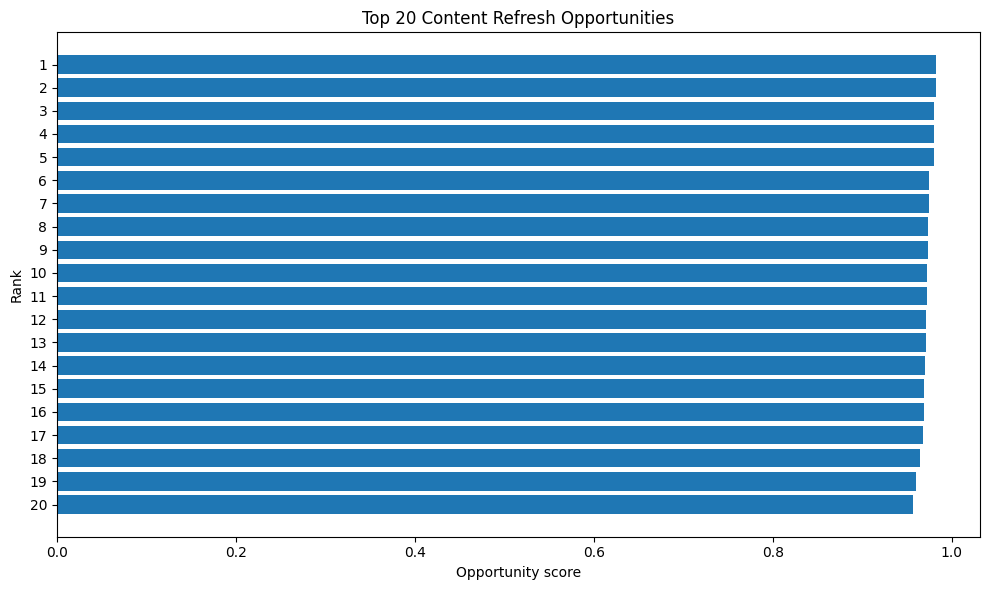

In [55]:
import matplotlib.pyplot as plt

top20 = recommendations.head(20).copy()

plt.figure(figsize=(10, 6))
plt.barh(
    top20["rank"].astype(str),
    top20["opportunity_score"]
)

plt.gca().invert_yaxis()
plt.xlabel("Opportunity score")
plt.ylabel("Rank")
plt.title("Top 20 Content Refresh Opportunities")
plt.tight_layout()
plt.show()

## 7. Artifacts the paper embeds

The paper includes a ranked recommendation table and a chart showing the highest-scoring pages in the held-out evaluation set.

The feature-importance chart is also included to show which observed signals contributed most to the model's discrimination.

These artifacts make the analysis easier to audit and connect the model output to practical content-review decisions.

## 7. Artifacts the paper embeds

The final analysis produces three main artifacts for the research paper:

1. A model-vs-baseline results table showing accuracy, precision, recall, F1, and ROC-AUC.
2. A feature-importance table showing which observed signals contributed most to the model.
3. A ranked recommendation table showing the highest-scoring pages for refresh/review.

These artifacts are intended for decision support and should be interpreted as directional evidence rather than causal conclusions.

In [56]:
# Section 7: Final artifacts

# Results artifact
results_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Baseline": [0.891, 0.000, 0.000, 0.000, np.nan],
    "ML Model": [0.878, 0.362, 0.155, 0.217, 0.801]
})

display(results_table)

# Feature importance artifact
display(importance)

# Ranked recommendations artifact
display(recommendations.head(20))

,Metric,Baseline,ML Model
0,Accuracy,0.891,0.878
1,Precision,0.000,0.362
2,Recall,0.000,0.155
3,F1,0.000,0.217
4,ROC-AUC,NaN,0.801


,feature,importance
0,impressions,0.195994
7,organic_sessions,0.053334
2,avg_position,0.015379
3,pageviews,0.008748
1,clicks,0.003849
6,engagement_seconds,0.000321
8,ai_sessions,0.000158
5,engaged_sessions,-0.000039
4,sessions,-0.002101


,impressions,clicks,avg_position,pageviews,sessions,engaged_sessions,engagement_seconds,organic_sessions,ai_sessions,opportunity_score,actual_outcome,rank
0,36962.0,0.0,5.881152,24.0,14.0,0.0,0.0,9.0,4.0,0.982313,0,1
1,16663.0,0.0,5.959721,4.0,4.0,0.0,0.0,0.0,0.0,0.981716,1,2
2,38865.0,0.0,5.694764,0.0,0.0,0.0,0.0,0.0,0.0,0.980186,1,3
3,11660.0,0.0,5.500902,0.0,0.0,0.0,0.0,0.0,0.0,0.980186,1,4
4,14482.0,0.0,7.569586,0.0,0.0,0.0,0.0,0.0,0.0,0.979879,0,5
5,128092.0,0.0,6.841330,1.0,1.0,0.0,0.0,0.0,0.0,0.974730,0,6
6,44707.0,0.0,7.906249,12.0,12.0,0.0,3.0,5.0,0.0,0.974676,1,7
7,19292.0,0.0,8.053905,1.0,1.0,0.0,0.0,0.0,0.0,0.973079,0,8
8,15902.0,0.0,7.973915,1.0,1.0,0.0,0.0,0.0,0.0,0.973079,0,9
9,12174.0,0.0,7.362553,7.0,7.0,1.0,10.0,0.0,0.0,0.972030,0,10


## ML-12: 5-Minute Demo Outline

1. **Question (1 min):** Explain the goal: identify pages that are strong candidates for refresh or review.
2. **Data (1 min):** Explain the FlyRank warehouse data, monthly page-level aggregation, and the historical time split.
3. **Method (1 min):** Explain the nine search/engagement features and the next-month positive-outcome label.
4. **Results (1 min):** Compare the majority baseline with the ML model. The model achieved ROC-AUC = 0.801 and precision = 0.362, while accuracy was slightly below the baseline.
5. **Recommendations (1 min):** Show the ranked opportunity list and explain that the scores are decision-support signals, not guarantees.

## Social-Post Cut

I built a machine-learning decision-support analysis using anonymized FlyRank search-performance data to rank pages for content refresh or review. The model achieved a ROC-AUC of 0.801 and 36.2% precision on a held-out time period, showing useful ranking signal while remaining below the majority baseline on accuracy. The output is a ranked opportunity list that can help content teams prioritize which pages to review first.

## Employer-Facing Summary

I built an end-to-end machine-learning workflow for ranking content refresh opportunities from historical search-performance data. I used a time-aware train/test split, checked for target leakage, compared the model with a majority-class baseline, and produced ranked recommendations. The final model showed useful discrimination (ROC-AUC = 0.801) while I reported its limitations and avoided causal claims.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
